# Monte Carlo Simulation for Value at Risk (VaR)
## Central Bank of Armenia — Refinancing Rate & USD/AMD Exchange Rate

This notebook performs a comprehensive **Monte Carlo simulation** to evaluate **Value at Risk (VaR)** using:
- **Վերdelays** (Refinancing Rate) from the Central Bank of Armenia
- **USD/AMD** exchange rate for joint risk modeling

### Methodology
| Component | Model | Description |
|-----------|-------|-------------|
| Exchange Rate | **Geometric Brownian Motion (GBM)** | Captures log-normal price dynamics |
| Refinancing Rate | **Vasicek Mean-Reversion** | Models interest rate's tendency to revert to long-run mean |
| Correlation | **Cholesky Decomposition** | Generates correlated random shocks |
| Risk Metric | **VaR & CVaR** | At 90%, 95%, and 99% confidence levels |

In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Project Structure Setup

Create a clean directory structure for a proper GitHub repository.

In [2]:
# 2. Define and Create Project Directory Structure
PROJECT_ROOT = Path('.')
DIRS = {
    'data': PROJECT_ROOT / 'data',
    'results': PROJECT_ROOT / 'results',
    'figures': PROJECT_ROOT / 'results' / 'figures',
    'tables': PROJECT_ROOT / 'results' / 'tables',
}

for name, path in DIRS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f'  Created: {path}')

print('\nRepository directory structure ready.')

  Created: data
  Created: results
  Created: results\figures
  Created: results\tables

Repository directory structure ready.


## 3. Data Loading & Preprocessing

Load the two datasets:
1. **Refinancing Rate** (`refinance rate.xlsx`) — Central Bank of Armenia policy rate decisions
2. **USD/AMD Exchange Rate** (`exchange rate.csv`) — Daily exchange rates

In [3]:
# 3. Load Data

# --- Refinancing Rate ---
df_ref = pd.read_excel('data/refinance rate.xlsx', header=1)
df_ref.columns = ['Date', 'Refinance_Rate', 'Lombard_Repo', 'Cash_Attraction']
df_ref['Date'] = pd.to_datetime(df_ref['Date'])
df_ref = df_ref.sort_values('Date').reset_index(drop=True)

print(f'Refinancing Rate:  {len(df_ref)} observations')
print(f'  Period: {df_ref["Date"].min().date()} to {df_ref["Date"].max().date()}')
print(f'  Current rate: {df_ref["Refinance_Rate"].iloc[-1]}%')

# --- USD/AMD Exchange Rate ---
df_fx = pd.read_csv('data/exchange rate.csv')
df_fx.columns = ['Date', 'EUR_AMD', 'RUB_AMD', 'USD_AMD']
df_fx['Date'] = pd.to_datetime(df_fx['Date'], format='%d.%m.%Y')
df_fx['USD_AMD'] = pd.to_numeric(df_fx['USD_AMD'], errors='coerce')
df_fx = df_fx.dropna(subset=['USD_AMD']).sort_values('Date').reset_index(drop=True)

print(f'\nUSD/AMD Rate:      {len(df_fx)} observations')
print(f'  Period: {df_fx["Date"].min().date()} to {df_fx["Date"].max().date()}')
print(f'  Current rate: {df_fx["USD_AMD"].iloc[-1]} AMD per 1 USD')

Refinancing Rate:  140 observations
  Period: 2004-03-08 to 2026-02-03
  Current rate: 6.5%

USD/AMD Rate:      6639 observations
  Period: 2000-01-01 to 2026-02-27
  Current rate: 377.0 AMD per 1 USD


In [4]:
# Preview the data
print('Refinancing Rate (last 10 decisions)')
display(df_ref[['Date', 'Refinance_Rate', 'Lombard_Repo', 'Cash_Attraction']].tail(10))

print('\nUSD/AMD Exchange Rate (last 10 days)')
display(df_fx[['Date', 'USD_AMD']].tail(10))

Refinancing Rate (last 10 decisions)


,Date,Refinance_Rate,Lombard_Repo,Cash_Attraction
130,2024-10-29,7.25,8.75,5.75
131,2024-12-10,7.00,8.50,5.50
132,2025-02-04,6.75,8.25,5.25
133,2025-03-18,6.75,8.25,5.25
134,2025-06-17,6.75,8.25,5.25
135,2025-08-05,6.75,8.25,5.25
136,2025-09-16,6.75,8.25,5.25
137,2025-11-04,6.75,8.25,5.25
138,2025-12-16,6.50,8.00,5.00
139,2026-02-03,6.50,8.00,5.00



USD/AMD Exchange Rate (last 10 days)


,Date,USD_AMD
6629,2026-02-16,377.67
6630,2026-02-17,376.83
6631,2026-02-18,377.69
6632,2026-02-19,376.94
6633,2026-02-20,376.82
6634,2026-02-23,376.97
6635,2026-02-24,377.84
6636,2026-02-25,376.92
6637,2026-02-26,377.04
6638,2026-02-27,377.00


## 4. Data Merging & Feature Engineering

The refinancing rate changes only at policy meetings, so we **forward-fill** it to create a daily series, then merge with the USD/AMD rate.

In [5]:
# 4. Create Daily Series and Merge

# Forward-fill refinancing rate to daily frequency
date_range = pd.date_range(df_ref['Date'].min(), df_fx['Date'].max(), freq='D')
df_ref_daily = pd.DataFrame({'Date': date_range})
df_ref_daily = df_ref_daily.merge(df_ref[['Date', 'Refinance_Rate']], on='Date', how='left')
df_ref_daily['Refinance_Rate'] = df_ref_daily['Refinance_Rate'].ffill()

# Merge datasets
df = df_fx[['Date', 'USD_AMD']].merge(df_ref_daily, on='Date', how='inner')
df = df.dropna().sort_values('Date').reset_index(drop=True)

# Compute returns / changes
df['FX_LogReturn'] = np.log(df['USD_AMD'] / df['USD_AMD'].shift(1))
df['Rate_Change_bps'] = (df['Refinance_Rate'] - df['Refinance_Rate'].shift(1)) * 100
df = df.dropna().reset_index(drop=True)

print(f'Merged dataset: {len(df)} daily observations')
print(f'  Period: {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

Merged dataset: 5538 daily observations
  Period: 2004-03-10 to 2026-02-27


,Date,USD_AMD,Refinance_Rate,FX_LogReturn,Rate_Change_bps
0,2004-03-10,564.79,9.0,0.000089,0.0
1,2004-03-11,565.03,9.0,0.000425,0.0
2,2004-03-12,562.42,9.0,-0.004630,0.0
3,2004-03-15,562.19,9.0,-0.000409,0.0
4,2004-03-16,562.30,9.0,0.000196,0.0


## 5. Exploratory Data Analysis

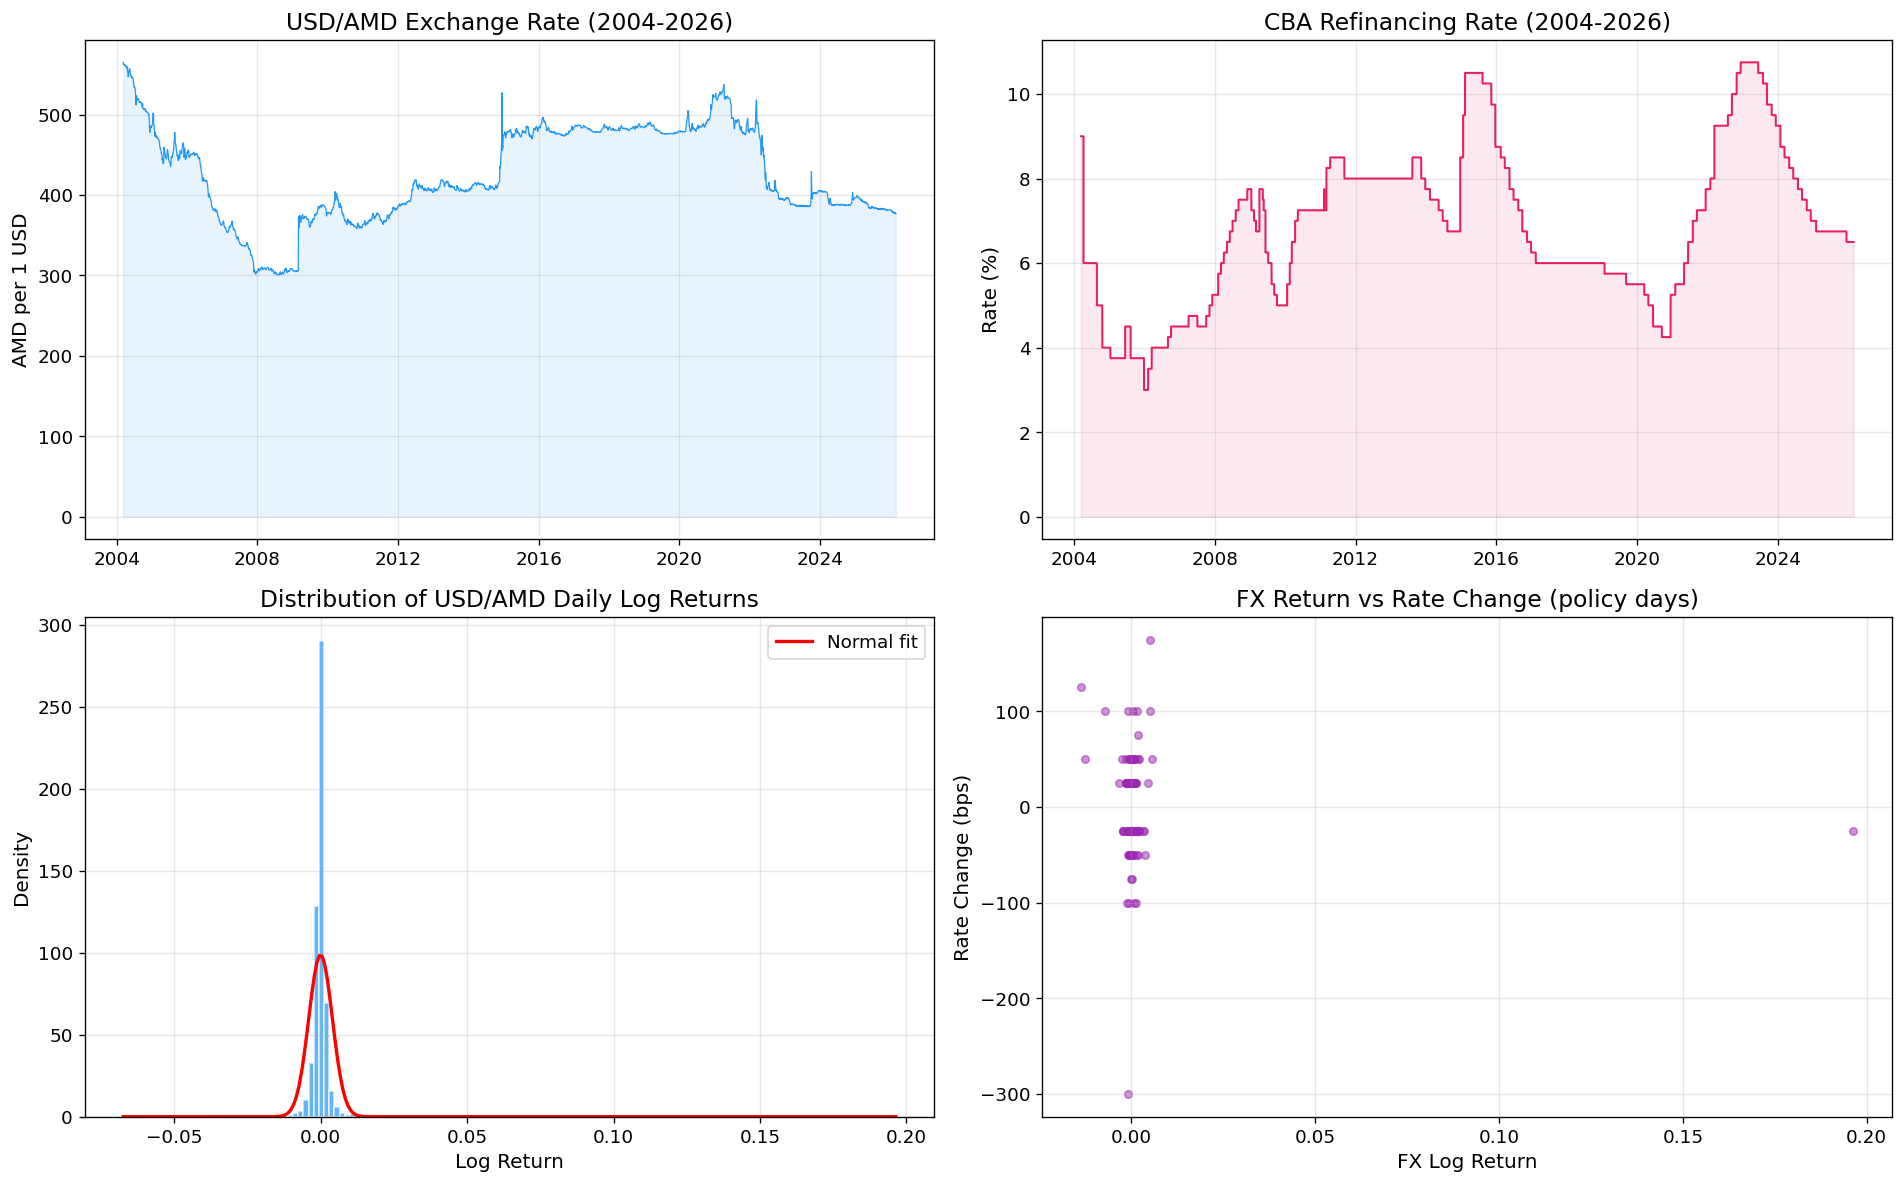

Saved: results/figures/historical_analysis.png


In [6]:
# 5a. Historical Plots

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# USD/AMD Historical
axes[0, 0].plot(df['Date'], df['USD_AMD'], color='#2196F3', linewidth=0.7)
axes[0, 0].set_title('USD/AMD Exchange Rate (2004-2026)')
axes[0, 0].set_ylabel('AMD per 1 USD')
axes[0, 0].fill_between(df['Date'], df['USD_AMD'], alpha=0.1, color='#2196F3')

# Refinancing Rate Historical
axes[0, 1].step(df['Date'], df['Refinance_Rate'], where='post', color='#E91E63', linewidth=1.2)
axes[0, 1].set_title('CBA Refinancing Rate (2004-2026)')
axes[0, 1].set_ylabel('Rate (%)')
axes[0, 1].fill_between(df['Date'], df['Refinance_Rate'], step='post', alpha=0.1, color='#E91E63')

# FX Log Returns Distribution
axes[1, 0].hist(df['FX_LogReturn'], bins=150, density=True, alpha=0.7, color='#2196F3', edgecolor='white')
axes[1, 0].set_title('Distribution of USD/AMD Daily Log Returns')
axes[1, 0].set_xlabel('Log Return')
axes[1, 0].set_ylabel('Density')
x_norm = np.linspace(df['FX_LogReturn'].min(), df['FX_LogReturn'].max(), 300)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, df['FX_LogReturn'].mean(), df['FX_LogReturn'].std()),
                'r-', linewidth=2, label='Normal fit')
axes[1, 0].legend()

# Scatter: FX return vs Rate change
mask = df['Rate_Change_bps'] != 0
axes[1, 1].scatter(df.loc[mask, 'FX_LogReturn'], df.loc[mask, 'Rate_Change_bps'],
                   alpha=0.5, s=20, color='#9C27B0')
axes[1, 1].set_title('FX Return vs Rate Change (policy days)')
axes[1, 1].set_xlabel('FX Log Return')
axes[1, 1].set_ylabel('Rate Change (bps)')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'historical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/historical_analysis.png')

In [7]:
# 5b. Descriptive Statistics

fx_returns = df['FX_LogReturn'].values
rate_changes = df['Rate_Change_bps'].values

desc_stats = pd.DataFrame({
    'USD/AMD Log Return': [
        fx_returns.mean(), fx_returns.std(),
        stats.skew(fx_returns), stats.kurtosis(fx_returns),
        np.percentile(fx_returns, 1), np.percentile(fx_returns, 5),
        np.percentile(fx_returns, 95), np.percentile(fx_returns, 99),
    ],
    'Refi Rate Change (bps)': [
        rate_changes.mean(), rate_changes.std(),
        stats.skew(rate_changes), stats.kurtosis(rate_changes),
        np.percentile(rate_changes, 1), np.percentile(rate_changes, 5),
        np.percentile(rate_changes, 95), np.percentile(rate_changes, 99),
    ]
}, index=['Mean', 'Std Dev', 'Skewness', 'Kurtosis',
          '1st Percentile', '5th Percentile', '95th Percentile', '99th Percentile'])

display(desc_stats.style.format('{:.6f}').set_caption('Descriptive Statistics'))

corr_val = df[['FX_LogReturn', 'Rate_Change_bps']].corr().iloc[0, 1]
print(f'\nCorrelation (FX log-return vs Rate change): {corr_val:.4f}')

desc_stats.to_csv(DIRS['tables'] / 'descriptive_statistics.csv')
print('Saved: results/tables/descriptive_statistics.csv')

,USD/AMD Log Return,Refi Rate Change (bps)
Mean,-0.000073,-0.045143
Std Dev,0.004042,7.906993
Skewness,20.924676,-6.888743
Kurtosis,1055.265882,480.201252
1st Percentile,-0.007479,-25.000000
5th Percentile,-0.003424,0.000000
95th Percentile,0.002909,0.000000
99th Percentile,0.007153,0.000000



Correlation (FX log-return vs Rate change): -0.0357
Saved: results/tables/descriptive_statistics.csv


## 6. Monte Carlo Simulation

### Model Specifications

**USD/AMD Exchange Rate — Geometric Brownian Motion (GBM):**

$$S_{t+1} = S_t \cdot \exp\left[(\mu - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\, Z_1\right]$$

**Refinancing Rate — Vasicek Mean-Reversion Model:**

$$r_{t+1} = r_t + \kappa(\theta - r_t)\Delta t + \sigma_r \sqrt{\Delta t}\, Z_2$$

where $Z_1, Z_2$ are correlated standard normal variables generated via **Cholesky decomposition**.

In [8]:
# 6a. Simulation Parameters

N_SIMULATIONS = 10_000
HORIZON_DAYS = 252
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]

S0_fx = df['USD_AMD'].iloc[-1]
S0_rate = df['Refinance_Rate'].iloc[-1]

print('MONTE CARLO SIMULATION PARAMETERS')
print('=' * 50)
print(f'  Simulations:        {N_SIMULATIONS:,}')
print(f'  Horizon:            {HORIZON_DAYS} trading days (~1 year)')
print(f'  Initial USD/AMD:    {S0_fx:.2f} AMD')
print(f'  Initial Refi Rate:  {S0_rate:.2f}%')

# GBM parameters
mu_fx = fx_returns.mean()
sigma_fx = fx_returns.std()

# Vasicek parameters via regression
rate_series = df['Refinance_Rate'].values
dr = np.diff(rate_series)
r_lag = rate_series[:-1]
mask_nz = dr != 0

if mask_nz.sum() > 5:
    b, a = np.polyfit(r_lag[mask_nz], dr[mask_nz], 1)
    kappa = max(-b, 0.01)
    theta = max(-a / b if b != 0 else rate_series.mean(), 1.0)
    sigma_r = max(np.std(dr[mask_nz]), 0.01)
else:
    kappa, theta, sigma_r = 0.1, rate_series.mean(), 0.25

# Correlation
valid_mask = (df['FX_LogReturn'] != 0) & (df['Rate_Change_bps'] != 0)
rho = np.corrcoef(df.loc[valid_mask, 'FX_LogReturn'],
                   df.loc[valid_mask, 'Rate_Change_bps'])[0, 1] if valid_mask.sum() > 2 else 0.0
rho = 0.0 if np.isnan(rho) else rho

print(f'\n  FX Model (GBM):      mu = {mu_fx:.6f}/day,  sigma = {sigma_fx:.6f}/day')
print(f'  Rate Model (Vasicek): kappa = {kappa:.4f},  theta = {theta:.2f}%,  sigma_r = {sigma_r:.4f}')
print(f'  Correlation (rho):    {rho:.4f}')

MONTE CARLO SIMULATION PARAMETERS
  Simulations:        10,000
  Horizon:            252 trading days (~1 year)
  Initial USD/AMD:    377.00 AMD
  Initial Refi Rate:  6.50%

  FX Model (GBM):      mu = -0.000073/day,  sigma = 0.004042/day
  Rate Model (Vasicek): kappa = 0.0588,  theta = 6.55%,  sigma_r = 0.5821
  Correlation (rho):    -0.0509


In [9]:
# 6b. Run Monte Carlo Simulation
np.random.seed(42)

cov_matrix = np.array([[1, rho], [rho, 1]])
try:
    L = np.linalg.cholesky(cov_matrix)
except np.linalg.LinAlgError:
    L = np.eye(2)

fx_paths = np.zeros((N_SIMULATIONS, HORIZON_DAYS + 1))
rate_paths = np.zeros((N_SIMULATIONS, HORIZON_DAYS + 1))
fx_paths[:, 0] = S0_fx
rate_paths[:, 0] = S0_rate

print('Running 10,000 simulations over 252 days...')
for t in range(1, HORIZON_DAYS + 1):
    Z = np.random.standard_normal((N_SIMULATIONS, 2))
    Z_corr = Z @ L.T

    # GBM for FX
    fx_paths[:, t] = fx_paths[:, t-1] * np.exp(
        (mu_fx - 0.5 * sigma_fx**2) + sigma_fx * Z_corr[:, 0]
    )
    # Vasicek for rate
    rate_paths[:, t] = (rate_paths[:, t-1]
                         + kappa * (theta - rate_paths[:, t-1])
                         + sigma_r * Z_corr[:, 1])
    rate_paths[:, t] = np.maximum(rate_paths[:, t], 0.0)

print('Simulation complete!')
print(f'  FX paths shape:   {fx_paths.shape}')
print(f'  Rate paths shape: {rate_paths.shape}')

Running 10,000 simulations over 252 days...
Simulation complete!
  FX paths shape:   (10000, 253)
  Rate paths shape: (10000, 253)


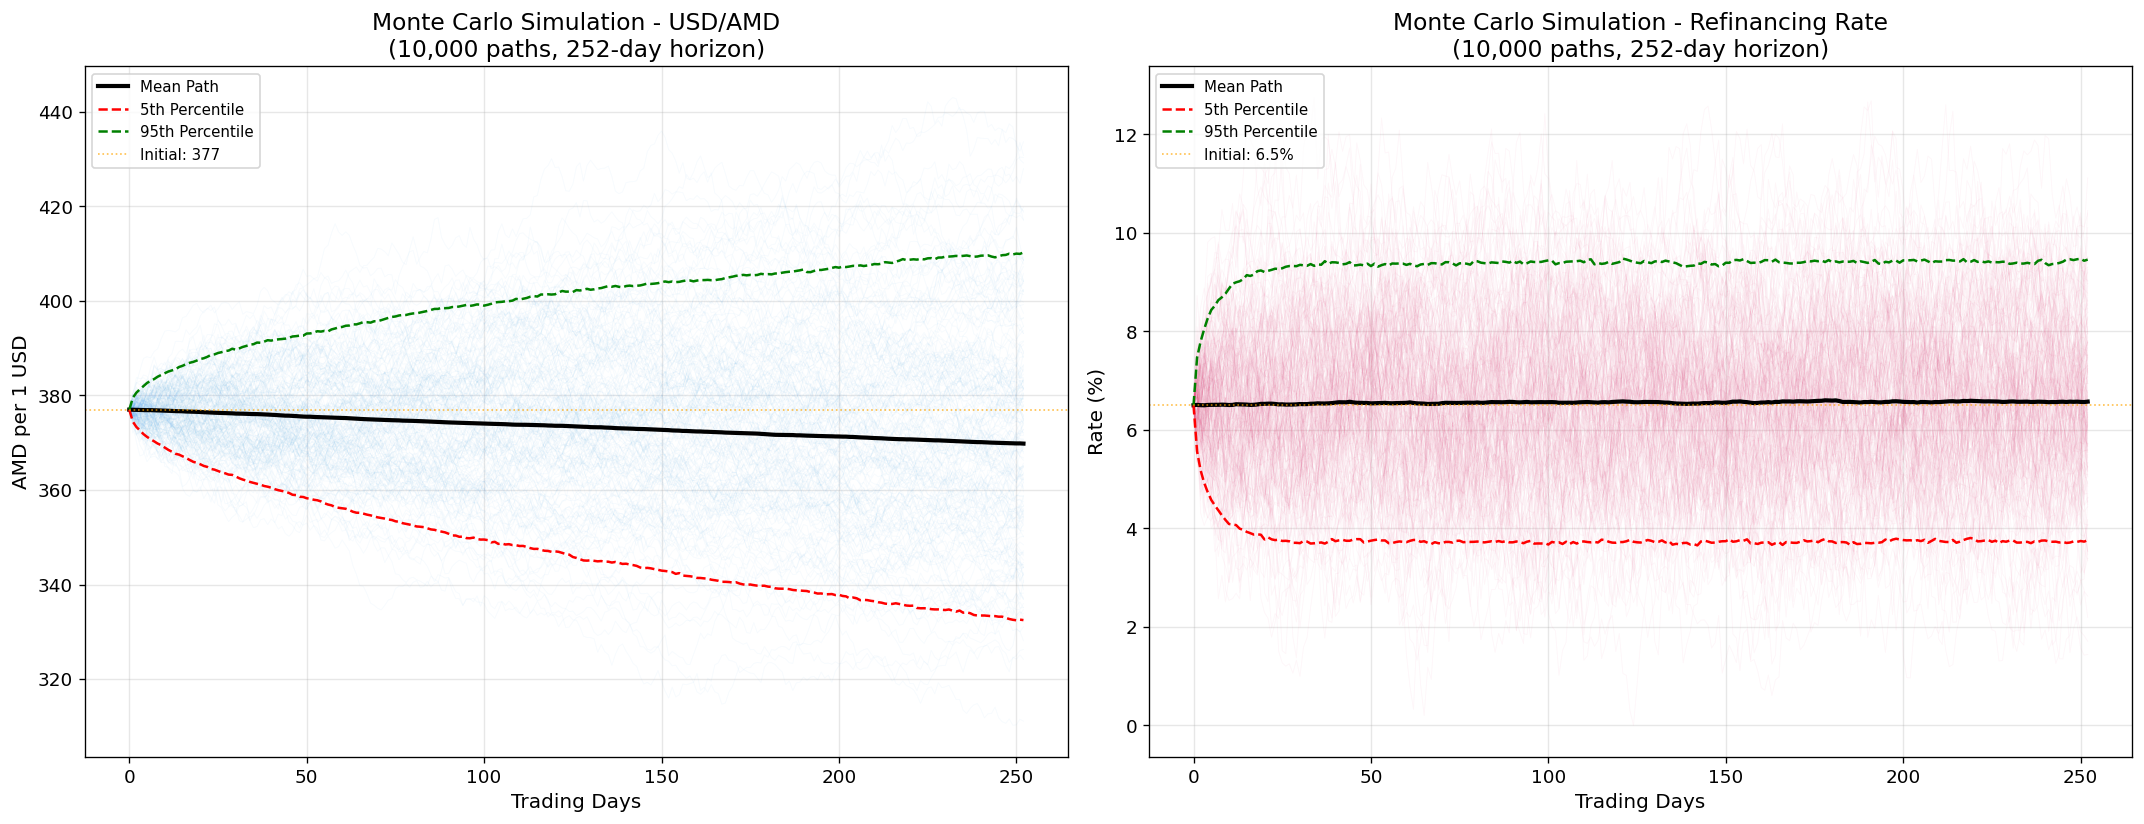

Saved: results/figures/simulated_paths.png


In [10]:
# 6c. Visualize Simulated Paths

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
time_axis = np.arange(HORIZON_DAYS + 1)
n_show = 200

# FX Paths
for i in range(n_show):
    axes[0].plot(time_axis, fx_paths[i], alpha=0.04, color='#2196F3', linewidth=0.5)
axes[0].plot(time_axis, np.mean(fx_paths, axis=0), 'k-', linewidth=2.5, label='Mean Path')
axes[0].plot(time_axis, np.percentile(fx_paths, 5, axis=0), 'r--', linewidth=1.5, label='5th Percentile')
axes[0].plot(time_axis, np.percentile(fx_paths, 95, axis=0), 'g--', linewidth=1.5, label='95th Percentile')
axes[0].axhline(S0_fx, color='orange', linestyle=':', linewidth=1, alpha=0.7, label=f'Initial: {S0_fx:.0f}')
axes[0].set_title(f'Monte Carlo Simulation - USD/AMD\n({N_SIMULATIONS:,} paths, {HORIZON_DAYS}-day horizon)')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('AMD per 1 USD')
axes[0].legend(loc='upper left', fontsize=9)

# Rate Paths
for i in range(n_show):
    axes[1].plot(time_axis, rate_paths[i], alpha=0.04, color='#E91E63', linewidth=0.5)
axes[1].plot(time_axis, np.mean(rate_paths, axis=0), 'k-', linewidth=2.5, label='Mean Path')
axes[1].plot(time_axis, np.percentile(rate_paths, 5, axis=0), 'r--', linewidth=1.5, label='5th Percentile')
axes[1].plot(time_axis, np.percentile(rate_paths, 95, axis=0), 'g--', linewidth=1.5, label='95th Percentile')
axes[1].axhline(S0_rate, color='orange', linestyle=':', linewidth=1, alpha=0.7, label=f'Initial: {S0_rate:.1f}%')
axes[1].set_title(f'Monte Carlo Simulation - Refinancing Rate\n({N_SIMULATIONS:,} paths, {HORIZON_DAYS}-day horizon)')
axes[1].set_xlabel('Trading Days')
axes[1].set_ylabel('Rate (%)')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'simulated_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/simulated_paths.png')

## 7. Value at Risk (VaR) & Expected Shortfall (CVaR)

**VaR** answers: *"What is the maximum loss at a given confidence level over a specified horizon?"*

**CVaR (Expected Shortfall)** answers: *"If the loss exceeds VaR, what is the average loss in the tail?"*

We compute VaR for:
1. **USD/AMD Exchange Rate** — risk of AMD depreciation/appreciation
2. **Refinancing Rate** — risk of rate increase/decrease
3. **Combined Portfolio** — joint FX + interest rate risk

In [11]:
# 7a. Compute P&L Distributions

fx_terminal = fx_paths[:, -1]
fx_pnl = fx_terminal - S0_fx
fx_pnl_pct = (fx_terminal / S0_fx - 1) * 100

rate_terminal = rate_paths[:, -1]
rate_pnl = rate_terminal - S0_rate
rate_pnl_bps = rate_pnl * 100

portfolio_initial = S0_fx * (1 + S0_rate / 100)
portfolio_terminal = fx_terminal * (1 + rate_terminal / 100)
portfolio_pnl = portfolio_terminal - portfolio_initial
portfolio_pnl_pct = (portfolio_terminal / portfolio_initial - 1) * 100

print('Terminal Distribution Summary:')
print(f'  USD/AMD:   mean={fx_terminal.mean():.2f}, std={fx_terminal.std():.2f}')
print(f'  Refi Rate: mean={rate_terminal.mean():.2f}%, std={rate_terminal.std():.2f}%')
print(f'  Portfolio: mean={portfolio_terminal.mean():.2f}, std={portfolio_terminal.std():.2f}')

Terminal Distribution Summary:
  USD/AMD:   mean=369.82, std=23.63
  Refi Rate: mean=6.57%, std=1.73%
  Portfolio: mean=394.12, std=25.90


In [12]:
# 7b. Calculate VaR and CVaR

results = []

print('=' * 75)
print('  VALUE AT RISK (VaR) & EXPECTED SHORTFALL (CVaR) RESULTS')
print('=' * 75)

# FX VaR
print(f'\n  USD/AMD Exchange Rate VaR ({HORIZON_DAYS}-day horizon)')
print(f'  Initial: {S0_fx:.2f} AMD/USD | Mean terminal: {fx_terminal.mean():.2f}')
for cl in CONFIDENCE_LEVELS:
    q = (1 - cl) * 100
    var_abs = np.percentile(fx_pnl, q)
    var_pct = np.percentile(fx_pnl_pct, q)
    es_abs = fx_pnl[fx_pnl <= var_abs].mean()
    es_pct = fx_pnl_pct[fx_pnl_pct <= var_pct].mean()
    print(f'\n  {cl*100:.0f}% Confidence:')
    print(f'    VaR:  {var_abs:+.2f} AMD ({var_pct:+.2f}%) -> floor: {S0_fx + var_abs:.2f}')
    print(f'    CVaR: {es_abs:+.2f} AMD ({es_pct:+.2f}%)')
    results.append({
        'Asset': 'USD/AMD', 'Confidence': f'{cl*100:.0f}%',
        'VaR (absolute)': round(var_abs, 2), 'VaR (%)': round(var_pct, 2),
        'CVaR (absolute)': round(es_abs, 2), 'CVaR (%)': round(es_pct, 2),
    })

# Rate VaR
print(f'\n{"-"*75}')
print(f'  Refinancing Rate VaR ({HORIZON_DAYS}-day horizon)')
print(f'  Initial: {S0_rate:.2f}% | Mean terminal: {rate_terminal.mean():.2f}%')
for cl in CONFIDENCE_LEVELS:
    q = (1 - cl) * 100
    var_pp = np.percentile(rate_pnl, q)
    var_bps = np.percentile(rate_pnl_bps, q)
    es_pp = rate_pnl[rate_pnl <= var_pp].mean()
    print(f'\n  {cl*100:.0f}% Confidence:')
    print(f'    VaR:  {var_pp:+.4f} pp ({var_bps:+.2f} bps) -> floor: {max(S0_rate + var_pp, 0):.2f}%')
    print(f'    CVaR: {es_pp:+.4f} pp')
    results.append({
        'Asset': 'Refi Rate', 'Confidence': f'{cl*100:.0f}%',
        'VaR (absolute)': round(var_pp, 4), 'VaR (%)': round(var_bps, 2),
        'CVaR (absolute)': round(es_pp, 4), 'CVaR (%)': None,
    })

# Portfolio VaR
print(f'\n{"-"*75}')
print(f'  Combined Portfolio VaR ({HORIZON_DAYS}-day horizon)')
print(f'  Initial: {portfolio_initial:.2f} AMD | Mean terminal: {portfolio_terminal.mean():.2f}')
for cl in CONFIDENCE_LEVELS:
    q = (1 - cl) * 100
    var_p = np.percentile(portfolio_pnl, q)
    var_p_pct = np.percentile(portfolio_pnl_pct, q)
    es_p = portfolio_pnl[portfolio_pnl <= var_p].mean()
    es_p_pct = portfolio_pnl_pct[portfolio_pnl_pct <= var_p_pct].mean()
    print(f'\n  {cl*100:.0f}% Confidence:')
    print(f'    VaR:  {var_p:+.2f} AMD ({var_p_pct:+.2f}%)')
    print(f'    CVaR: {es_p:+.2f} AMD ({es_p_pct:+.2f}%)')
    results.append({
        'Asset': 'Portfolio', 'Confidence': f'{cl*100:.0f}%',
        'VaR (absolute)': round(var_p, 2), 'VaR (%)': round(var_p_pct, 2),
        'CVaR (absolute)': round(es_p, 2), 'CVaR (%)': round(es_p_pct, 2),
    })

df_results = pd.DataFrame(results)

  VALUE AT RISK (VaR) & EXPECTED SHORTFALL (CVaR) RESULTS

  USD/AMD Exchange Rate VaR (252-day horizon)
  Initial: 377.00 AMD/USD | Mean terminal: 369.82

  90% Confidence:
    VaR:  -37.14 AMD (-9.85%) -> floor: 339.86
    CVaR: -46.82 AMD (-12.42%)

  95% Confidence:
    VaR:  -44.52 AMD (-11.81%) -> floor: 332.48
    CVaR: -52.90 AMD (-14.03%)

  99% Confidence:
    VaR:  -57.91 AMD (-15.36%) -> floor: 319.09
    CVaR: -65.05 AMD (-17.26%)

---------------------------------------------------------------------------
  Refinancing Rate VaR (252-day horizon)
  Initial: 6.50% | Mean terminal: 6.57%

  90% Confidence:
    VaR:  -2.1556 pp (-215.56 bps) -> floor: 4.34%
    CVaR: -2.9636 pp

  95% Confidence:
    VaR:  -2.7416 pp (-274.16 bps) -> floor: 3.76%
    CVaR: -3.4992 pp

  99% Confidence:
    VaR:  -4.0174 pp (-401.74 bps) -> floor: 2.48%
    CVaR: -4.5713 pp

---------------------------------------------------------------------------
  Combined Portfolio VaR (252-day horizon)
 

In [13]:
# 7c. VaR Summary Table

print('VaR SUMMARY TABLE')
print('=' * 75)
display(df_results.style.set_caption(f'VaR & CVaR Results - {HORIZON_DAYS}-Day Horizon, {N_SIMULATIONS:,} Simulations'))

df_results.to_csv(DIRS['tables'] / 'var_results.csv', index=False)
print('\nSaved: results/tables/var_results.csv')

VaR SUMMARY TABLE


,Asset,Confidence,VaR (absolute),VaR (%),CVaR (absolute),CVaR (%)
0,USD/AMD,90%,-37.140000,-9.850000,-46.820000,-12.420000
1,USD/AMD,95%,-44.520000,-11.810000,-52.900000,-14.030000
2,USD/AMD,99%,-57.910000,-15.360000,-65.050000,-17.260000
3,Refi Rate,90%,-2.155600,-215.560000,-2.963600,nan
4,Refi Rate,95%,-2.741600,-274.160000,-3.499200,nan
5,Refi Rate,99%,-4.017400,-401.740000,-4.571300,nan
6,Portfolio,90%,-39.860000,-9.930000,-50.800000,-12.650000
7,Portfolio,95%,-48.510000,-12.080000,-57.640000,-14.350000
8,Portfolio,99%,-63.800000,-15.890000,-71.430000,-17.790000



Saved: results/tables/var_results.csv


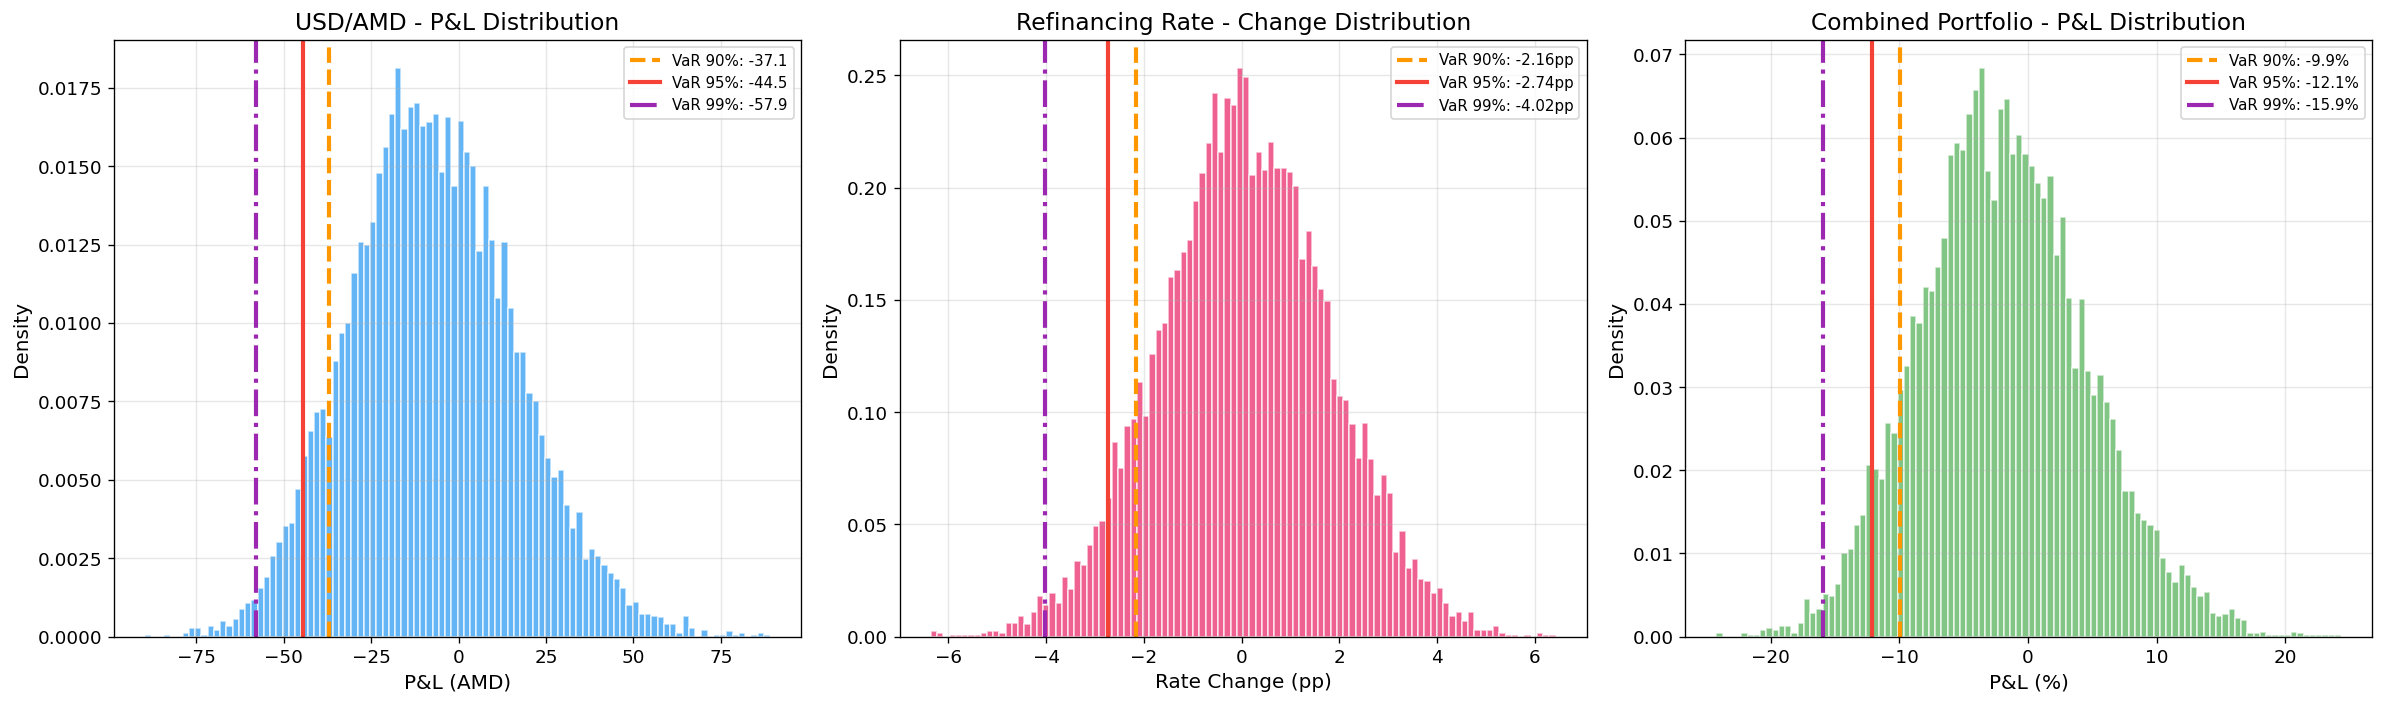

Saved: results/figures/var_distributions.png


In [14]:
# 7d. VaR Visualization - P&L Distributions

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_cl = {'90%': '#FF9800', '95%': '#F44336', '99%': '#9C27B0'}
ls_cl = {'90%': '--', '95%': '-', '99%': '-.'}

# FX P&L
axes[0].hist(fx_pnl, bins=100, density=True, alpha=0.7, color='#2196F3', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(fx_pnl, (1-cl)*100)
    lbl = f'{cl*100:.0f}%'
    axes[0].axvline(v, color=colors_cl[lbl], linestyle=ls_cl[lbl], linewidth=2.5,
                    label=f'VaR {lbl}: {v:+.1f}')
axes[0].set_title('USD/AMD - P&L Distribution')
axes[0].set_xlabel('P&L (AMD)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Rate P&L
axes[1].hist(rate_pnl, bins=100, density=True, alpha=0.7, color='#E91E63', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(rate_pnl, (1-cl)*100)
    lbl = f'{cl*100:.0f}%'
    axes[1].axvline(v, color=colors_cl[lbl], linestyle=ls_cl[lbl], linewidth=2.5,
                    label=f'VaR {lbl}: {v:+.2f}pp')
axes[1].set_title('Refinancing Rate - Change Distribution')
axes[1].set_xlabel('Rate Change (pp)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# Portfolio P&L
axes[2].hist(portfolio_pnl_pct, bins=100, density=True, alpha=0.7, color='#4CAF50', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(portfolio_pnl_pct, (1-cl)*100)
    lbl = f'{cl*100:.0f}%'
    axes[2].axvline(v, color=colors_cl[lbl], linestyle=ls_cl[lbl], linewidth=2.5,
                    label=f'VaR {lbl}: {v:+.1f}%')
axes[2].set_title('Combined Portfolio - P&L Distribution')
axes[2].set_xlabel('P&L (%)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'var_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/var_distributions.png')

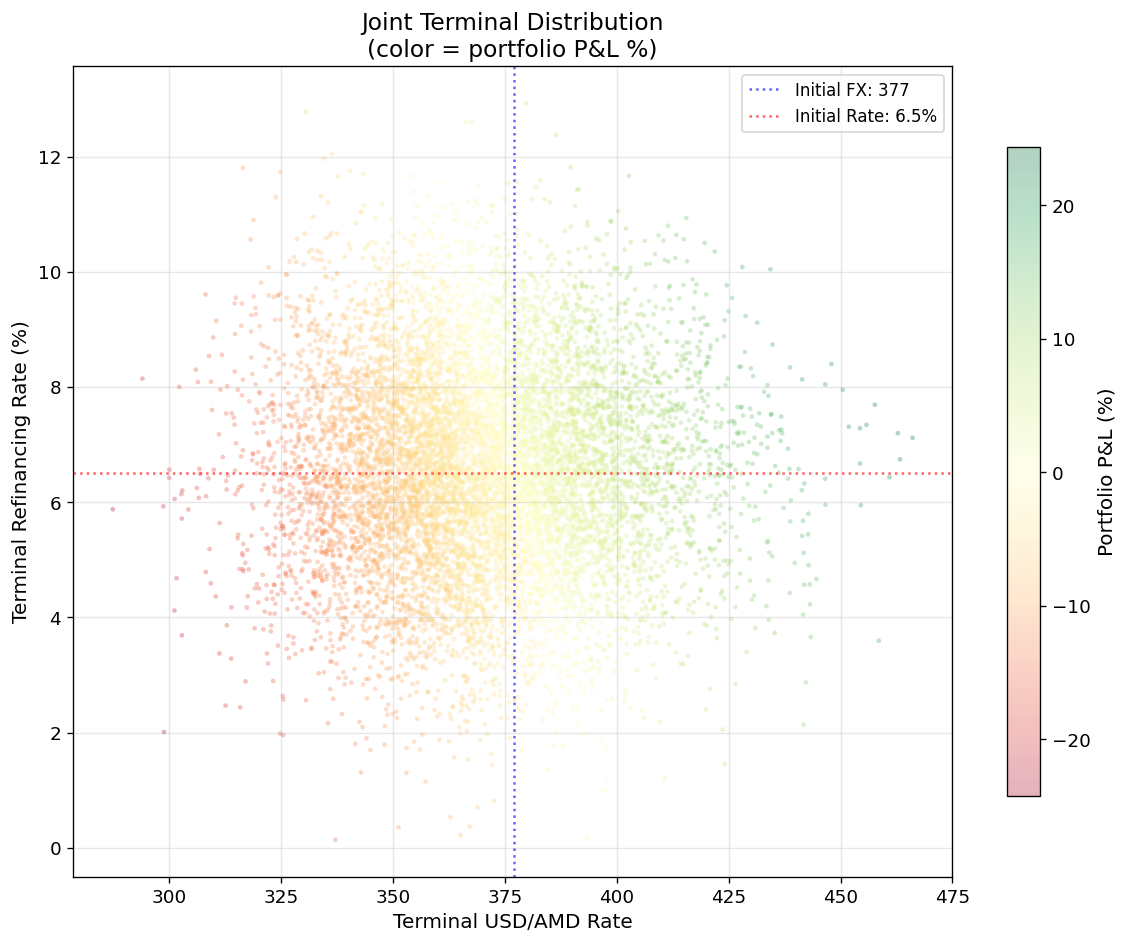

Saved: results/figures/joint_terminal_distribution.png


In [15]:
# 7e. Joint Terminal Distribution Scatter

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(fx_terminal, rate_terminal, c=portfolio_pnl_pct,
                     cmap='RdYlGn', alpha=0.3, s=8, edgecolors='none')
ax.axvline(S0_fx, color='blue', linestyle=':', alpha=0.6, label=f'Initial FX: {S0_fx:.0f}')
ax.axhline(S0_rate, color='red', linestyle=':', alpha=0.6, label=f'Initial Rate: {S0_rate}%')
ax.set_xlabel('Terminal USD/AMD Rate')
ax.set_ylabel('Terminal Refinancing Rate (%)')
ax.set_title('Joint Terminal Distribution\n(color = portfolio P&L %)')
plt.colorbar(scatter, ax=ax, label='Portfolio P&L (%)', shrink=0.8)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(DIRS['figures'] / 'joint_terminal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/joint_terminal_distribution.png')

## 8. Comprehensive Results Dashboard

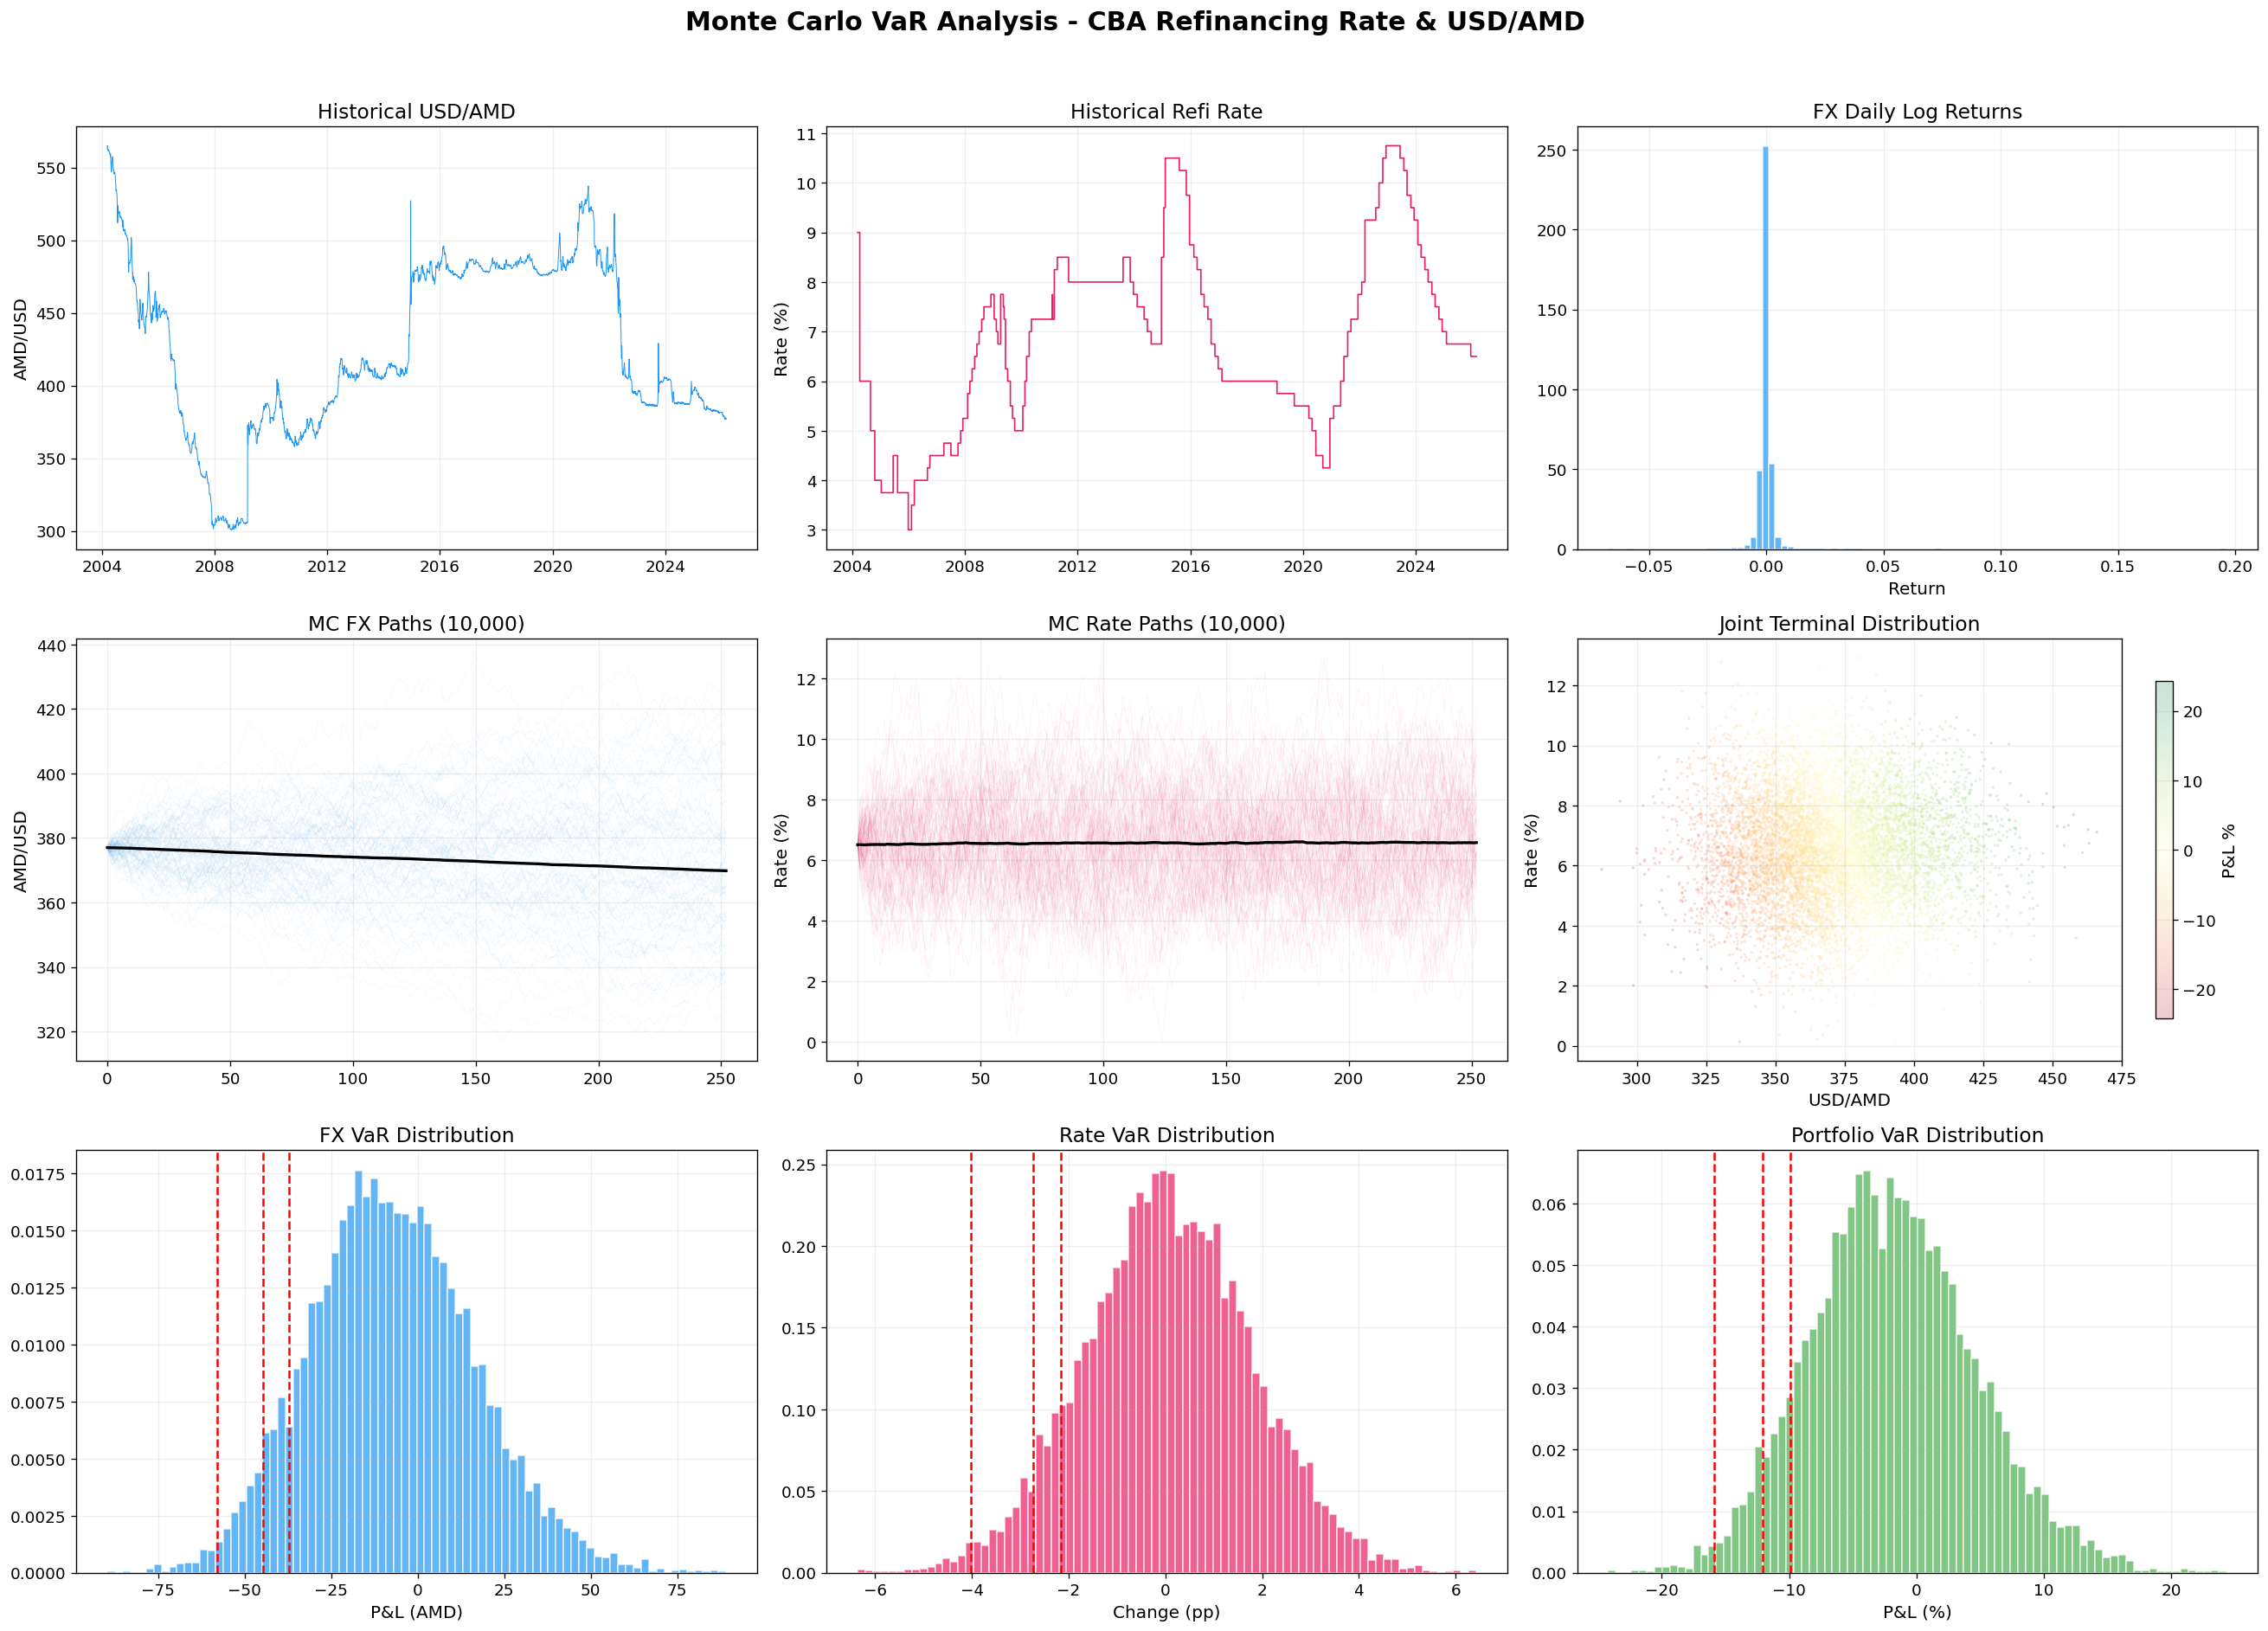

Saved: results/figures/full_dashboard.png


In [16]:
# 8. Full Dashboard

fig = plt.figure(figsize=(22, 16))
fig.suptitle('Monte Carlo VaR Analysis - CBA Refinancing Rate & USD/AMD',
             fontsize=18, fontweight='bold', y=0.98)

ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(df['Date'], df['USD_AMD'], color='#2196F3', linewidth=0.6)
ax1.set_title('Historical USD/AMD')
ax1.set_ylabel('AMD/USD')

ax2 = fig.add_subplot(3, 3, 2)
ax2.step(df['Date'], df['Refinance_Rate'], where='post', color='#E91E63', linewidth=1)
ax2.set_title('Historical Refi Rate')
ax2.set_ylabel('Rate (%)')

ax3 = fig.add_subplot(3, 3, 3)
ax3.hist(df['FX_LogReturn'], bins=100, density=True, alpha=0.7, color='#2196F3', edgecolor='white')
ax3.set_title('FX Daily Log Returns')
ax3.set_xlabel('Return')

ax4 = fig.add_subplot(3, 3, 4)
for i in range(100):
    ax4.plot(time_axis, fx_paths[i], alpha=0.05, color='#2196F3', linewidth=0.5)
ax4.plot(time_axis, np.mean(fx_paths, axis=0), 'k-', linewidth=2)
ax4.set_title(f'MC FX Paths ({N_SIMULATIONS:,})')
ax4.set_ylabel('AMD/USD')

ax5 = fig.add_subplot(3, 3, 5)
for i in range(100):
    ax5.plot(time_axis, rate_paths[i], alpha=0.05, color='#E91E63', linewidth=0.5)
ax5.plot(time_axis, np.mean(rate_paths, axis=0), 'k-', linewidth=2)
ax5.set_title(f'MC Rate Paths ({N_SIMULATIONS:,})')
ax5.set_ylabel('Rate (%)')

ax6 = fig.add_subplot(3, 3, 6)
sc = ax6.scatter(fx_terminal, rate_terminal, c=portfolio_pnl_pct,
                 cmap='RdYlGn', alpha=0.2, s=4, edgecolors='none')
ax6.set_title('Joint Terminal Distribution')
ax6.set_xlabel('USD/AMD')
ax6.set_ylabel('Rate (%)')
plt.colorbar(sc, ax=ax6, label='P&L %', shrink=0.8)

ax7 = fig.add_subplot(3, 3, 7)
ax7.hist(fx_pnl, bins=80, density=True, alpha=0.7, color='#2196F3', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(fx_pnl, (1-cl)*100)
    ax7.axvline(v, color='red', linestyle='--', linewidth=1.5)
ax7.set_title('FX VaR Distribution')
ax7.set_xlabel('P&L (AMD)')

ax8 = fig.add_subplot(3, 3, 8)
ax8.hist(rate_pnl, bins=80, density=True, alpha=0.7, color='#E91E63', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(rate_pnl, (1-cl)*100)
    ax8.axvline(v, color='red', linestyle='--', linewidth=1.5)
ax8.set_title('Rate VaR Distribution')
ax8.set_xlabel('Change (pp)')

ax9 = fig.add_subplot(3, 3, 9)
ax9.hist(portfolio_pnl_pct, bins=80, density=True, alpha=0.7, color='#4CAF50', edgecolor='white')
for cl in CONFIDENCE_LEVELS:
    v = np.percentile(portfolio_pnl_pct, (1-cl)*100)
    ax9.axvline(v, color='red', linestyle='--', linewidth=1.5)
ax9.set_title('Portfolio VaR Distribution')
ax9.set_xlabel('P&L (%)')

for ax in fig.get_axes():
    ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(DIRS['figures'] / 'full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/full_dashboard.png')

## 9. Save All Results & Generate Repository Files

In [17]:
# 9a. Save Metrics JSON

metrics = {
    'simulation': {
        'n_simulations': N_SIMULATIONS,
        'horizon_days': HORIZON_DAYS,
        'initial_fx_rate': float(S0_fx),
        'initial_refi_rate': float(S0_rate),
        'seed': 42,
    },
    'model_parameters': {
        'fx_gbm': {'mu': float(mu_fx), 'sigma': float(sigma_fx)},
        'vasicek': {'kappa': float(kappa), 'theta': float(theta), 'sigma_r': float(sigma_r)},
        'correlation_rho': float(rho),
    },
    'var_results': {
        'fx_usd_amd': {},
        'refinancing_rate': {},
        'combined_portfolio': {},
    }
}

for cl in CONFIDENCE_LEVELS:
    q = (1 - cl) * 100
    key = f'{cl*100:.0f}pct'
    metrics['var_results']['fx_usd_amd'][key] = {
        'var_amd': round(float(np.percentile(fx_pnl, q)), 2),
        'var_pct': round(float(np.percentile(fx_pnl_pct, q)), 2),
        'cvar_amd': round(float(fx_pnl[fx_pnl <= np.percentile(fx_pnl, q)].mean()), 2),
    }
    metrics['var_results']['refinancing_rate'][key] = {
        'var_pp': round(float(np.percentile(rate_pnl, q)), 4),
        'var_bps': round(float(np.percentile(rate_pnl_bps, q)), 2),
        'cvar_pp': round(float(rate_pnl[rate_pnl <= np.percentile(rate_pnl, q)].mean()), 4),
    }
    metrics['var_results']['combined_portfolio'][key] = {
        'var_amd': round(float(np.percentile(portfolio_pnl, q)), 2),
        'var_pct': round(float(np.percentile(portfolio_pnl_pct, q)), 2),
        'cvar_amd': round(float(portfolio_pnl[portfolio_pnl <= np.percentile(portfolio_pnl, q)].mean()), 2),
    }

with open(DIRS['results'] / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: results/metrics.json')
print(json.dumps(metrics, indent=2))

Saved: results/metrics.json
{
  "simulation": {
    "n_simulations": 10000,
    "horizon_days": 252,
    "initial_fx_rate": 377.0,
    "initial_refi_rate": 6.5,
    "seed": 42
  },
  "model_parameters": {
    "fx_gbm": {
      "mu": -7.297223921873437e-05,
      "sigma": 0.00404169436019367
    },
    "vasicek": {
      "kappa": 0.058783268255464385,
      "theta": 6.553636190112619,
      "sigma_r": 0.5821168729949785
    },
    "correlation_rho": -0.050906796250352306
  },
  "var_results": {
    "fx_usd_amd": {
      "90pct": {
        "var_amd": -37.14,
        "var_pct": -9.85,
        "cvar_amd": -46.82
      },
      "95pct": {
        "var_amd": -44.52,
        "var_pct": -11.81,
        "cvar_amd": -52.9
      },
      "99pct": {
        "var_amd": -57.91,
        "var_pct": -15.36,
        "cvar_amd": -65.05
      }
    },
    "refinancing_rate": {
      "90pct": {
        "var_pp": -2.1556,
        "var_bps": -215.56,
        "cvar_pp": -2.9636
      },
      "95pct": {
     

In [18]:
# 9b. Generate README.md

var_table_rows = ""
for cl in CONFIDENCE_LEVELS:
    q = (1 - cl) * 100
    cl_str = f"{cl*100:.0f}%"
    fx_v = np.percentile(fx_pnl, q)
    fx_v_pct = np.percentile(fx_pnl_pct, q)
    fx_cv = fx_pnl[fx_pnl <= fx_v].mean()
    rate_v = np.percentile(rate_pnl, q)
    rate_v_bps = np.percentile(rate_pnl_bps, q)
    port_v_pct = np.percentile(portfolio_pnl_pct, q)
    port_cv = portfolio_pnl[portfolio_pnl <= np.percentile(portfolio_pnl, q)].mean()
    var_table_rows += f"| {cl_str} | {fx_v:+.2f} AMD ({fx_v_pct:+.2f}%) | {fx_cv:+.2f} AMD | {rate_v:+.4f} pp ({rate_v_bps:+.1f} bps) | {port_v_pct:+.2f}% | {port_cv:+.2f} AMD |\n"

readme_content = f"""# Monte Carlo Simulation — Value at Risk (VaR)

## Central Bank of Armenia: Refinancing Rate & USD/AMD Exchange Rate

> Monte Carlo simulation for **Value at Risk (VaR)** and **Expected Shortfall (CVaR)** analysis using the CBA refinancing rate and USD/AMD exchange rate.

---

## Overview

This project implements a **Monte Carlo simulation** to evaluate **Value at Risk (VaR)** and **Expected Shortfall (CVaR)** for:

- **USD/AMD Exchange Rate** — modeled using Geometric Brownian Motion (GBM)
- **CBA Refinancing Rate** — modeled using Vasicek mean-reversion
- **Combined Portfolio** — joint FX + interest rate risk with correlated shocks

The simulation generates **{N_SIMULATIONS:,} scenarios** over a **{HORIZON_DAYS}-day (~1 year) horizon** using historical data from 2004-2026.

---

## Repository Structure

```
Monte Carlo Simulation/
|-- Monte_Carlo_VaR.ipynb          # Main Jupyter notebook (full analysis)
|-- monte_carlo_var.py              # Standalone Python script
|-- refinance rate.xlsx             # CBA refinancing rate data (2004-2026)
|-- exchange rate.csv               # USD/AMD daily exchange rates (2000-2026)
|-- data/                           # Data directory
|-- results/
|   |-- metrics.json                # All numerical results in JSON format
|   |-- figures/
|   |   |-- historical_analysis.png
|   |   |-- simulated_paths.png
|   |   |-- var_distributions.png
|   |   |-- joint_terminal_distribution.png
|   |   |-- full_dashboard.png
|   |-- tables/
|       |-- descriptive_statistics.csv
|       |-- var_results.csv
|-- requirements.txt
|-- .gitignore
|-- README.md
```

---

## Methodology

### Models Used

| Component | Model | Description |
|-----------|-------|-------------|
| Exchange Rate | **Geometric Brownian Motion** | Log-normal price dynamics for FX |
| Refinancing Rate | **Vasicek Mean-Reversion** | Interest rate mean-reversion model |
| Correlation | **Cholesky Decomposition** | Correlated shocks from bivariate normal |

### Estimated Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| mu (FX drift) | {mu_fx:.6f} | Daily mean log return |
| sigma (FX vol) | {sigma_fx:.6f} | Daily volatility |
| kappa (mean reversion) | {kappa:.4f} | Speed of mean reversion |
| theta (long-run mean) | {theta:.2f}% | Long-run equilibrium rate |
| sigma_r (rate vol) | {sigma_r:.4f} | Rate volatility |
| rho (correlation) | {rho:.4f} | FX-Rate correlation |

---

## Key Results

### Initial Conditions (as of {df['Date'].max().date()})

| Metric | Value |
|--------|-------|
| USD/AMD Rate | **{S0_fx:.2f}** AMD per 1 USD |
| Refinancing Rate | **{S0_rate:.2f}%** |
| Simulation Horizon | **{HORIZON_DAYS} trading days** (~1 year) |
| Number of Simulations | **{N_SIMULATIONS:,}** |

### VaR & CVaR Summary ({HORIZON_DAYS}-Day Horizon)

| Confidence | FX VaR | FX CVaR | Rate VaR | Portfolio VaR | Portfolio CVaR |
|:----------:|:------:|:-------:|:--------:|:-------------:|:--------------:|
{var_table_rows}
### Interpretation

- With **95% confidence** over 1 year:
  - The USD/AMD rate will not fall below **~{S0_fx + np.percentile(fx_pnl, 5):.0f} AMD/USD** (from {S0_fx:.0f})
  - The refinancing rate will not drop below **~{max(S0_rate + np.percentile(rate_pnl, 5), 0):.2f}%** (from {S0_rate:.1f}%)
  - Combined portfolio loss will not exceed **{abs(np.percentile(portfolio_pnl_pct, 5)):.1f}%**

- At **99% confidence**, the worst-case FX loss is **{abs(np.percentile(fx_pnl, 1)):.0f} AMD**

---

## Visualizations

### Historical Data & Exploratory Analysis
![Historical Analysis](results/figures/historical_analysis.png)

### Monte Carlo Simulated Paths
![Simulated Paths](results/figures/simulated_paths.png)

### VaR Distributions
![VaR Distributions](results/figures/var_distributions.png)

### Joint Terminal Distribution
![Joint Distribution](results/figures/joint_terminal_distribution.png)

### Full Dashboard
![Dashboard](results/figures/full_dashboard.png)

---

## Installation & Usage

### Prerequisites

```bash
pip install -r requirements.txt
```

### Run the Notebook

```bash
jupyter notebook Monte_Carlo_VaR.ipynb
```

### Run the Script

```bash
python monte_carlo_var.py
```

---

## Data Sources

| Dataset | Source | Period |
|---------|--------|--------|
| Refinancing Rate | [Central Bank of Armenia](https://www.cba.am) | 2004-2026 |
| USD/AMD Exchange Rate | [Central Bank of Armenia](https://www.cba.am) | 2000-2026 |

---

## Technologies

- **Python 3.13**
- **NumPy** — numerical computations & random number generation
- **Pandas** — data manipulation & analysis
- **Matplotlib** — visualizations
- **SciPy** — statistical functions
- **OpenPyXL** — Excel file reading

---

## License

This project is for educational purposes at YSUE (Yerevan State University of Economics).

---

*Generated on {pd.Timestamp.now().strftime('%Y-%m-%d')}*
"""

with open(PROJECT_ROOT / 'README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print('README.md generated successfully!')
print(f'  Length: {len(readme_content):,} characters')

README.md generated successfully!
  Length: 4,802 characters


In [19]:
# 9c. Create .gitignore

gitignore_content = """# Python
__pycache__/
*.py[cod]
*$py.class
*.so
*.egg-info/
dist/
build/
*.egg

# Jupyter
.ipynb_checkpoints/

# Virtual environments
venv/
env/
.venv/
.env

# OS files
.DS_Store
Thumbs.db
desktop.ini

# IDE
.vscode/
.idea/
*.swp
*.swo

# Distribution
*.tar.gz
*.whl
"""

with open(PROJECT_ROOT / '.gitignore', 'w') as f:
    f.write(gitignore_content)
print('Created: .gitignore')

# 9d. Create requirements.txt

requirements_content = """numpy>=1.24.0
pandas>=2.0.0
matplotlib>=3.7.0
scipy>=1.10.0
openpyxl>=3.1.0
"""

with open(PROJECT_ROOT / 'requirements.txt', 'w') as f:
    f.write(requirements_content)
print('Created: requirements.txt')

Created: .gitignore
Created: requirements.txt


In [20]:
# 10. Display Final Repository Structure

print('=' * 50)
print('  FINAL REPOSITORY STRUCTURE')
print('=' * 50)

exclude_dirs = {'.git', '__pycache__', '.ipynb_checkpoints'}
exclude_files = {'monte_carlo_var_results.png'}

for root, dirs, files in os.walk(PROJECT_ROOT):
    dirs[:] = [d for d in sorted(dirs) if d not in exclude_dirs]
    level = root.replace(str(PROJECT_ROOT), '').count(os.sep)
    indent = '    ' * level
    folder_name = os.path.basename(root) or '.'
    print(f'{indent}{folder_name}/')
    subindent = '    ' * (level + 1)
    for f in sorted(files):
        if f not in exclude_files:
            size = os.path.getsize(os.path.join(root, f))
            if size > 1024 * 1024:
                size_str = f"{size/1024/1024:.1f} MB"
            elif size > 1024:
                size_str = f"{size/1024:.1f} KB"
            else:
                size_str = f"{size} B"
            print(f'{subindent}{f}  ({size_str})')

print('\n' + '=' * 50)
print('  Repository is ready for GitHub!')
print('=' * 50)
print('\nNext steps:')
print('  1. git init')
print('  2. git add .')
print('  3. git commit -m "Initial commit: Monte Carlo VaR analysis"')
print('  4. git remote add origin <your-repo-url>')
print('  5. git push -u origin main')

  FINAL REPOSITORY STRUCTURE
./
    .gitignore  (300 B)
    Monte_Carlo_VaR.ipynb  (42.2 KB)
    README.md  (4.9 KB)
    exchange rate.csv  (248.1 KB)
    monte_carlo_var.py  (20.4 KB)
    refinance rate.xlsx  (10.0 KB)
    requirements.txt  (81 B)
    .venv/
        .gitignore  (2 B)
        pyvenv.cfg  (130 B)
        Include/
        Lib/
            site-packages/
                distutils-precedence.pth  (152 B)
                numpy-2.0.2-cp39-cp39-win_amd64.whl  (0 B)
                pylab.py  (110 B)
                scipy-1.13.1-cp39-cp39-win_amd64.whl  (0 B)
                six.py  (33.9 KB)
                PIL/
                    AvifImagePlugin.py  (9.1 KB)
                    BdfFontFile.py  (3.3 KB)
                    BlpImagePlugin.py  (16.6 KB)
                    BmpImagePlugin.py  (19.9 KB)
                    BufrStubImagePlugin.py  (1.8 KB)
                    ContainerIO.py  (4.7 KB)
                    CurImagePlugin.py  (1.8 KB)
                    DcxImagePlugi